In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

df = pd.read_excel("Airtel_Money.xlsx")
df.head()

size_of_dataset = df.shape
types_and_names_of_columns = df.dtypes
info_about_dataset = df.info()
number_of_rows = df.shape[0]
number_of_columns = df.shape[1]
number_of_empty_in_dataset = df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction Type  4 non-null      object 
 1   Amount(TZS)       4 non-null      float64
 2   Date & Time       73 non-null     object 
 3   Details           73 non-null     object 
 4   Credited          72 non-null     object 
 5   Debited           72 non-null     object 
 6   Balance           72 non-null     float64
dtypes: float64(2), object(5)
memory usage: 4.1+ KB


In [149]:
# Extract only the date portion from mixed formats
df['date_only'] = df['Date & Time'].astype(str).str.extract(r'(\d{2}/\d{2}/\d{2})')

# Convert to datetime
df['date'] = pd.to_datetime(df['date_only'], format="%d/%m/%y", errors="coerce")

# Remove old column
df = df.drop(columns=['Date & Time'])


In [150]:
df = df.rename(columns={
    "Details": "description",
    "Credited": "received",
    "Debited": "sent",
    "Balance": "balance"
})

clean_df = df[["date", "description", "sent", "received", "balance"]]

In [151]:
clean_df.head()

,date,description,sent,received,balance
0,2025-10-12,Money Sent to MNOs MNOs (MP251012.1828.W00864),20540,--,614811.26
1,2025-10-13,Money Sent to MNOs MNOs (MP251013.1123.S73887),372070,--,242741.26
2,2025-10-13,null AISHA MWAMIA (PP251013.2301.V82071),10000,--,232741.26
3,2025-10-14,Money Sent to MNOs MNOs (MP251014.0904.M03449),201710,--,31031.26
4,2025-10-14,Money Sent to MNOs MNOs (MP251014.1019.Q38807),30612,--,419.26


In [152]:
clean_df["received"] = pd.to_numeric(clean_df["received"], errors="coerce")
clean_df["sent"] = pd.to_numeric(clean_df["sent"], errors="coerce")
clean_df["balance"] = pd.to_numeric(clean_df["balance"], errors="coerce")

C:\Users\awadh\AppData\Local\Temp\ipykernel_19340\91656425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["received"] = pd.to_numeric(clean_df["received"], errors="coerce")
C:\Users\awadh\AppData\Local\Temp\ipykernel_19340\91656425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["sent"] = pd.to_numeric(clean_df["sent"], errors="coerce")
C:\Users\awadh\AppData\Local\Temp\ipykernel_19340\91656425.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [153]:
clean_df['date'] = clean_df['date'].fillna(method='ffill')
clean_df = clean_df[~(clean_df['sent'].isna() & clean_df['received'].isna())]


# clean_df[clean_df.sent.isna()]
# clean_df[clean_df.received.isna()]
# clean_df[clean_df.balance.isna()]
# clean_df[clean_df.date.isna()]
# clean_df[clean_df.description.isna()]



C:\Users\awadh\AppData\Local\Temp\ipykernel_19340\2459426680.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_df['date'] = clean_df['date'].fillna(method='ffill')
C:\Users\awadh\AppData\Local\Temp\ipykernel_19340\2459426680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['date'] = clean_df['date'].fillna(method='ffill')


In [154]:
total_Sent = clean_df["sent"].sum()
total_Received = clean_df["received"].sum()

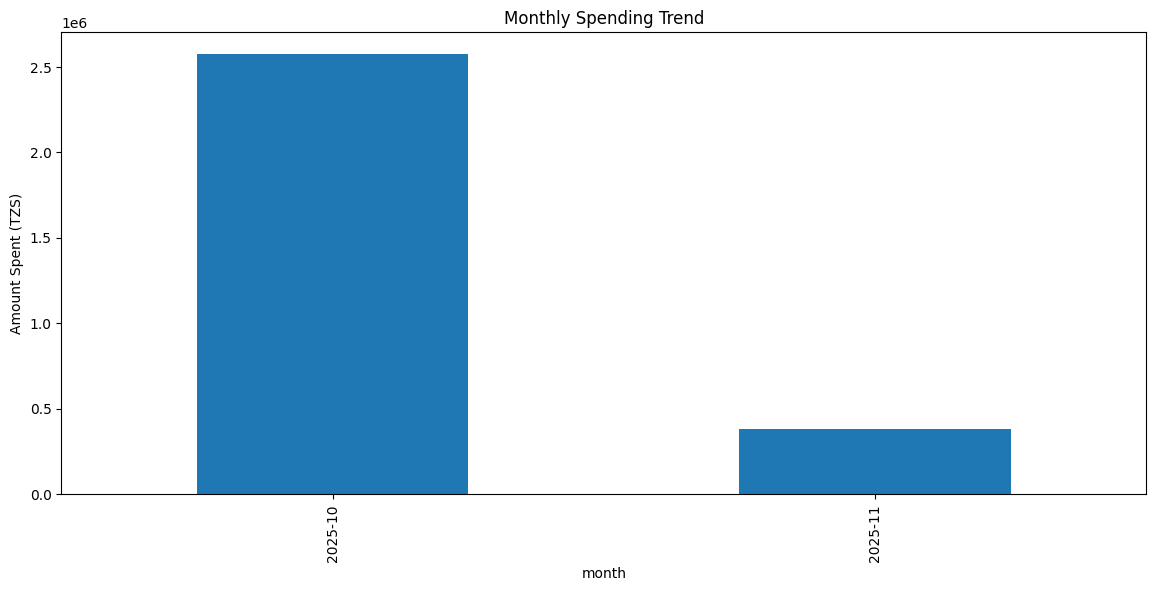

In [ ]:
daily_spending_trend_over_time = clean_df.groupby("date")["sent"].sum()
daily_spending_trend_over_time.sort_values(ascending=False).head(5)

clean_df["week"] = clean_df["date"].dt.isocalendar().week
clean_df["year"] = clean_df["date"].dt.year
weekly_spending = clean_df.groupby(["year", "week"])["sent"].sum()
weekly_spending.sort_values(ascending=False).head(5)

clean_df["month"] = clean_df["date"].dt.to_period("M")
monthly_spending = clean_df.groupby("month")["sent"].sum()
monthly_spending.sort_values(ascending=False).head(5)

# Visualize and save daily spending trend
plt.figure(figsize=(14, 6))
daily_spending_trend_over_time.plot(kind='line', marker='o')
plt.title('Daily Spending Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amount Sent (TZS)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/daily_spending_trend.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize and save weekly spending
plt.figure(figsize=(12, 6))
weekly_spending.plot(kind='bar')
plt.title('Weekly Spending Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Week (Year-Week)', fontsize=12)
plt.ylabel('Amount Sent (TZS)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/weekly_spending.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize and save monthly spending
plt.figure(figsize=(10, 6))
monthly_spending.plot(kind='bar', color='coral')
plt.title('Monthly Spending Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount Sent (TZS)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/monthly_spending.png', dpi=300, bbox_inches='tight')
plt.show()

# Print insights
print("\n" + "="*60)
print("TOP 5 DAILY SPENDING DAYS:")
print("="*60)
print(daily_spending_trend_over_time.sort_values(ascending=False).head(5))
print("\n" + "="*60)
print("TOP 5 WEEKLY SPENDING:")
print("="*60)
print(weekly_spending.sort_values(ascending=False).head(5))
print("\n" + "="*60)
print("MONTHLY SPENDING SUMMARY:")
print("="*60)
print(monthly_spending.sort_values(ascending=False))
print("="*60)


In [ ]:
clean_df["category"] = clean_df["description"].str.extract(r'([A-Za-z]+)')

clean_df["category"].value_counts()

category_totals = clean_df.groupby("category")["sent"].sum()
category_totals.sort_values(ascending=False).head(5)


category
Money      2625644.0
null        325296.0
Airtime       5000.0
MP             510.0
Name: sent, dtype: float64

category
Money Sent         34
Money Deposit      22
Money Withdrawn     6
Name: count, dtype: int64
                      sent   received
category                             
Money Deposit          0.0  2321791.0
Money Sent       2030504.0        0.0
Money Withdrawn   595140.0        0.0


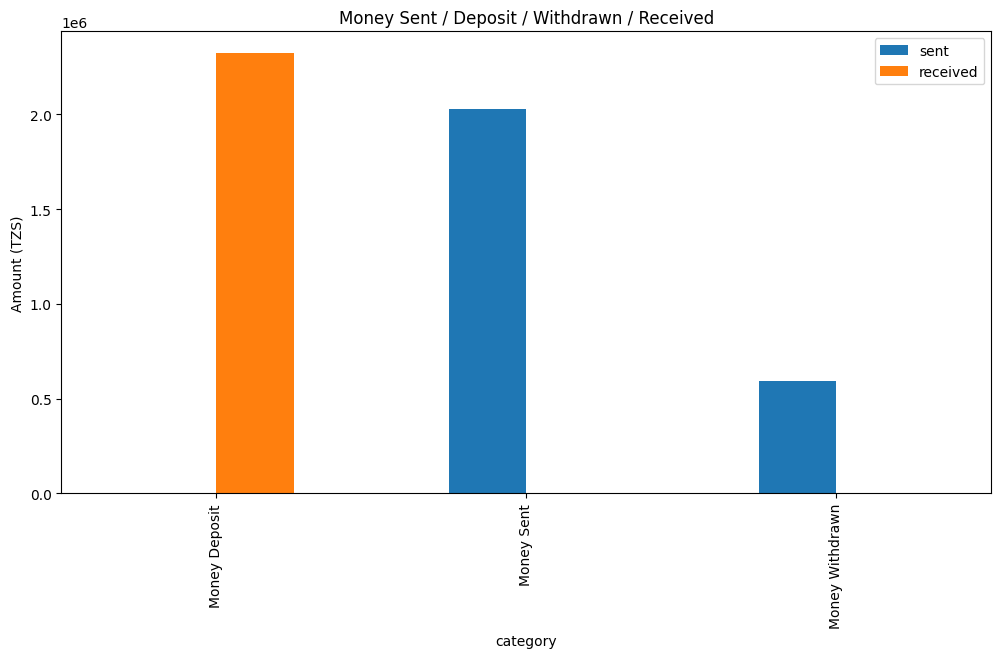

In [ ]:
# 1. Extract real category (first two words: Money Sent, Money Deposit, etc.)
clean_df['category'] = clean_df['description'].str.extract(r'^(Money\s+\w+)')

# 2. View categories
print(clean_df['category'].value_counts())

# 3. Calculate totals
category_totals = clean_df.groupby("category")[["sent", "received"]].sum()
print(category_totals)

# 4. Visualize and save
plt.figure(figsize=(12,6))
category_totals.plot(kind="bar")
plt.title("Money Sent / Deposit / Withdrawn / Received", fontsize=14, fontweight='bold')
plt.ylabel("Amount (TZS)", fontsize=12)
plt.xlabel("Category", fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Sent', 'Received'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plots/category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
